# Classification Report (Logistic Regression)

# 1. Libraries

In [6]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

# for solve problem of show plotly plots
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

from warnings import filterwarnings
filterwarnings('ignore')
plt.style.use('_mpl-gallery')

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn import metrics

# 2. Loading Data

In [4]:
# import diabetes dataset
df = pd.read_csv("../data/diabetes.csv")
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


# 3.Model

In [12]:
# define x and y for modeling
x = df.drop('outcome', axis=1)
y = df.outcome

In [13]:
scaler = StandardScaler()
x_norm = scaler.fit_transform(x)
x_norm

array([[ 0.63994726,  0.84832379,  0.14964075, ...,  0.20401277,
         0.46849198,  1.4259954 ],
       [-0.84488505, -1.12339636, -0.16054575, ..., -0.68442195,
        -0.36506078, -0.19067191],
       [ 1.23388019,  1.94372388, -0.26394125, ..., -1.10325546,
         0.60439732, -0.10558415],
       ...,
       [ 0.3429808 ,  0.00330087,  0.14964075, ..., -0.73518964,
        -0.68519336, -0.27575966],
       [-0.84488505,  0.1597866 , -0.47073225, ..., -0.24020459,
        -0.37110101,  1.17073215],
       [-0.84488505, -0.8730192 ,  0.04624525, ..., -0.20212881,
        -0.47378505, -0.87137393]])

In [14]:
# convert x_train_st to DataFrame
x = pd.DataFrame(x_norm, index=x.index, columns=x.columns)
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.848324,0.149641,0.907270,-0.692891,0.204013,0.468492,1.425995
1,-0.844885,-1.123396,-0.160546,0.530902,-0.692891,-0.684422,-0.365061,-0.190672
2,1.233880,1.943724,-0.263941,-1.288212,-0.692891,-1.103255,0.604397,-0.105584
3,-0.844885,-0.998208,-0.160546,0.154533,0.123302,-0.494043,-0.920763,-1.041549
4,-1.141852,0.504055,-1.504687,0.907270,0.765836,1.409746,5.484909,-0.020496
...,...,...,...,...,...,...,...,...
763,1.827813,-0.622642,0.356432,1.722735,0.870031,0.115169,-0.908682,2.532136
764,-0.547919,0.034598,0.046245,0.405445,-0.692891,0.610154,-0.398282,-0.531023
765,0.342981,0.003301,0.149641,0.154533,0.279594,-0.735190,-0.685193,-0.275760
766,-0.844885,0.159787,-0.470732,-1.288212,-0.692891,-0.240205,-0.371101,1.170732


In [16]:
# split data to train and test
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [25]:
# define model and fit model
model = LogisticRegression(C=1)
model.fit(X_train, y_train)

# prediction and results
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)


In [26]:
X_train.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
603,0.936914,0.910918,0.459827,0.530902,0.401154,0.407084,0.664800,1.766346
118,0.046014,-0.747831,-0.470732,0.154533,-0.692891,-0.481351,-0.087210,-0.956462
247,-1.141852,1.380375,1.080200,0.781814,5.211479,2.577403,-0.135532,-0.871374
157,-0.844885,-0.372265,-0.677523,0.029077,0.479300,-0.862109,1.090636,-0.871374
468,1.233880,-0.027996,-3.572597,-1.288212,-0.692891,-0.252897,-0.872441,0.404942


In [27]:
model.intercept_

array([-0.80681994])

In [28]:
model.coef_

array([[ 0.30335575,  1.06569305, -0.25804901,  0.06824812, -0.15513941,
         0.68183886,  0.2920388 ,  0.23473908]])

In [30]:
y_pred

array([1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0])

In [31]:
y_pred_proba

array([[0.03694269, 0.96305731],
       [0.83342466, 0.16657534],
       [0.91444707, 0.08555293],
       [0.32682894, 0.67317106],
       [0.88844804, 0.11155196],
       [0.96308101, 0.03691899],
       [0.2344009 , 0.7655991 ],
       [0.13046621, 0.86953379],
       [0.6098598 , 0.3901402 ],
       [0.64213513, 0.35786487],
       [0.40784333, 0.59215667],
       [0.03015772, 0.96984228],
       [0.74078509, 0.25921491],
       [0.83703811, 0.16296189],
       [0.90305967, 0.09694033],
       [0.860131  , 0.139869  ],
       [0.12215747, 0.87784253],
       [0.97750562, 0.02249438],
       [0.62474075, 0.37525925],
       [0.74446107, 0.25553893],
       [0.34570923, 0.65429077],
       [0.55738474, 0.44261526],
       [0.92116814, 0.07883186],
       [0.95263558, 0.04736442],
       [0.94864262, 0.05135738],
       [0.65941533, 0.34058467],
       [0.96143501, 0.03856499],
       [0.07984503, 0.92015497],
       [0.90067025, 0.09932975],
       [0.8646061 , 0.1353939 ],
       [0.

In [21]:
from sklearn.metrics import classification_report

target_names = ['without diabetes', 'with diabetes']
print(classification_report(y_test, y_pred, target_names=target_names))

                  precision    recall  f1-score   support

without diabetes       0.84      0.92      0.88       107
   with diabetes       0.76      0.62      0.68        47

        accuracy                           0.82       154
       macro avg       0.80      0.77      0.78       154
    weighted avg       0.82      0.82      0.82       154



Text(0.5, 203.55555555555554, 'Predicted label')

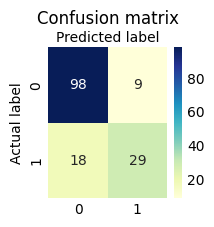

In [22]:
from sklearn import metrics

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)

class_names=['without diabetes', 'with diabetes'] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [55]:
from sklearn.metrics import roc_curve
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# y_test: actual binary labels (e.g., [0, 1, 0, 1, 1])
# y_pred_proba[:,1] predicted probabilities for the positive class (e.g., [0.2, 0.8, 0.3, 0.9, 0.6])
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:,1])

In [75]:
print("fpr", fpr)

fpr [0.         0.         0.         0.01869159 0.01869159 0.02803738
 0.02803738 0.05607477 0.05607477 0.06542056 0.06542056 0.07476636
 0.07476636 0.14018692 0.14018692 0.14953271 0.14953271 0.1588785
 0.1588785  0.19626168 0.19626168 0.25233645 0.25233645 0.26168224
 0.26168224 0.29906542 0.29906542 0.30841121 0.30841121 0.3271028
 0.3271028  0.34579439 0.34579439 0.37383178 0.37383178 0.44859813
 0.44859813 0.45794393 0.45794393 0.8411215  0.8411215  1.        ]


In [76]:
print("tpr", tpr)

tpr [0.         0.0212766  0.04255319 0.04255319 0.27659574 0.27659574
 0.46808511 0.46808511 0.4893617  0.4893617  0.59574468 0.59574468
 0.61702128 0.61702128 0.65957447 0.65957447 0.68085106 0.68085106
 0.72340426 0.72340426 0.74468085 0.74468085 0.78723404 0.78723404
 0.82978723 0.82978723 0.85106383 0.85106383 0.87234043 0.87234043
 0.89361702 0.89361702 0.91489362 0.91489362 0.93617021 0.93617021
 0.95744681 0.95744681 0.9787234  0.9787234  1.         1.        ]


In [77]:
thresholds

array([       inf, 0.96031648, 0.95935294, 0.90930924, 0.74437012,
       0.73899423, 0.66207291, 0.6444444 , 0.6338    , 0.62915508,
       0.55168839, 0.5358792 , 0.52155086, 0.45422568, 0.43058268,
       0.42719416, 0.42533997, 0.4136515 , 0.40542331, 0.39015285,
       0.38605636, 0.36369747, 0.36289728, 0.36213525, 0.34629493,
       0.31819767, 0.30508803, 0.30396521, 0.30343125, 0.29366137,
       0.28959854, 0.28796909, 0.28118192, 0.25267085, 0.24864605,
       0.2052183 , 0.20304581, 0.20251128, 0.19472247, 0.07472218,
       0.07400245, 0.00285195])

In [79]:
from sklearn.metrics import roc_auc_score
# y_test: actual binary labels
# y_score: predicted probabilities or decision function values

auc_score = roc_auc_score(y_test, y_pred_proba[:,1])

In [80]:
print("auc_score", auc_score)

auc_score 0.8661761781666335


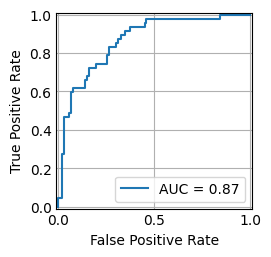

In [52]:
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc_score)
display.plot()
plt.show()

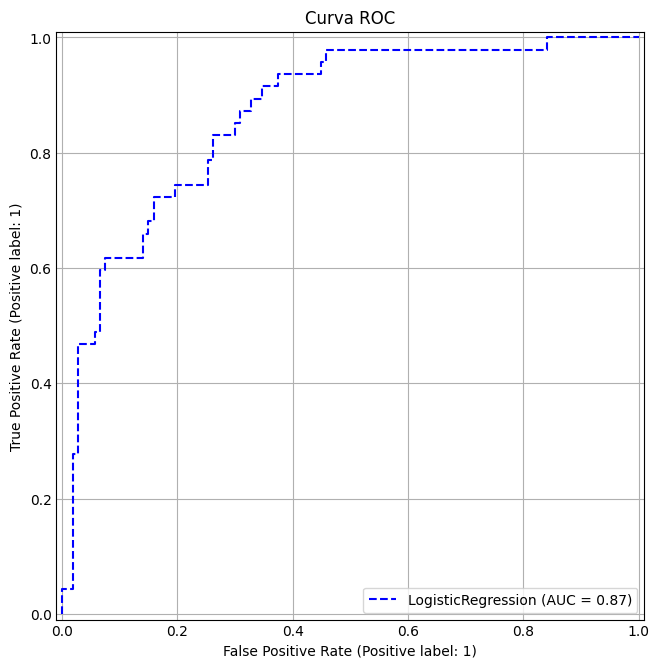

In [73]:
from sklearn.metrics import DetCurveDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 6)

color = "blue"
linestyle = "--"

RocCurveDisplay.from_estimator(
        model, X_test, y_test, curve_kwargs=dict(color=color, linestyle=linestyle),
    )

plt.title("Curva ROC")
plt.show()

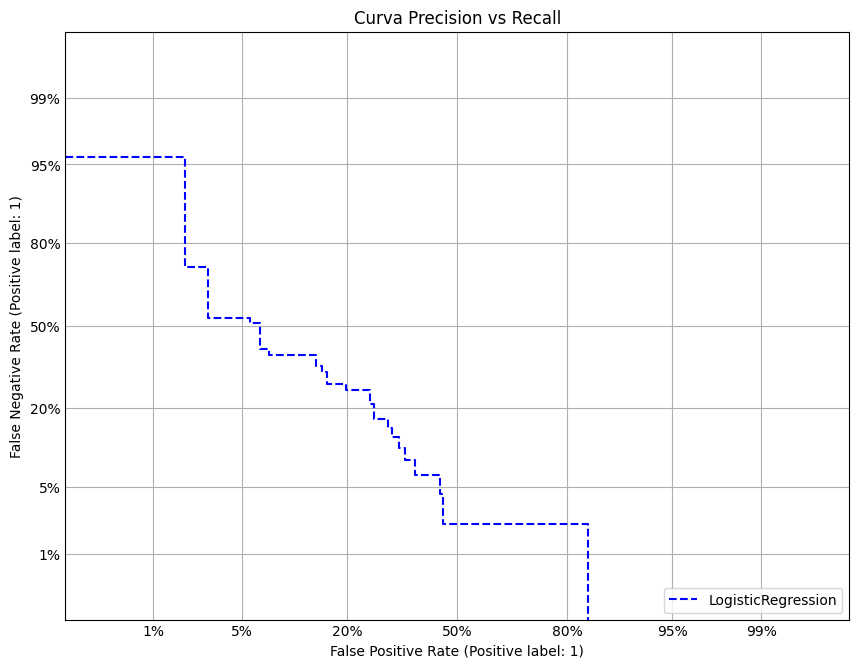

In [74]:
DetCurveDisplay.from_estimator(
        model, X_test, y_test, color=color, linestyle=linestyle
    )
plt.title("Curva Precision vs Recall")
plt.show()